# 기말 프로젝트: 영화 리뷰 감성 분석



In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Device:", device)


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Device: cuda


## 1. 데이터 불러오기

학습 데이터, 테스트 데이터, sample submission 파일, GloVe 임베딩 파일을 불러왔다.  


In [3]:
DATA_DIR = "./data"

train_path = os.path.join(DATA_DIR, "train.tsv")
test_path = os.path.join(DATA_DIR, "test.tsv")
sample_path = os.path.join(DATA_DIR, "sampleSubmission.csv")
glove_path = os.path.join(DATA_DIR, "glove.6B.100d.txt")

train_df = pd.read_csv(train_path, sep="\t")
test_df = pd.read_csv(test_path, sep="\t")
sample_df = pd.read_csv(sample_path)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("sample shape:", sample_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nSample columns:")
print(sample_df.columns.tolist())

train_df.head()

train shape: (156060, 4)
test shape: (66292, 3)
sample shape: (66292, 2)

Train columns:
['PhraseId', 'SentenceId', 'Phrase', 'Sentiment']

Test columns:
['PhraseId', 'SentenceId', 'Phrase']

Sample columns:
['PhraseId', 'Sentiment']


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


## 2. Label 분포 확인

모델 학습 전에 5개 감성 label의 분포를 확인하였다.  
감성 label은 0부터 4까지로 구성되어 있으며, 중립에 해당하는 label 2의 비중이 가장 높게 나타났다.  
따라서 train-validation split 과정에서는 label 비율이 유지되도록 stratified split을 사용하였다.

Sentiment
0     7072
1    27273
2    79582
3    32927
4     9206
Name: count, dtype: int64


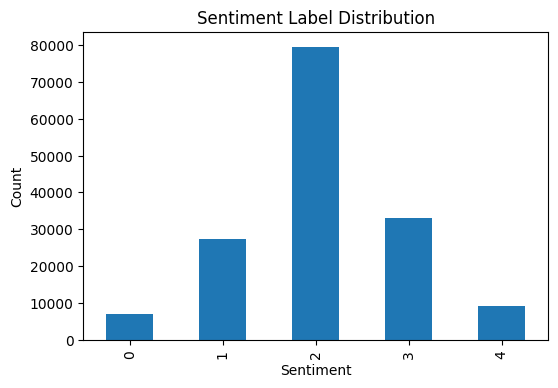

In [4]:
# Label distribution 확인
print(train_df["Sentiment"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
train_df["Sentiment"].value_counts().sort_index().plot(kind="bar")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 3. 텍스트 전처리

원문 문장은 소문자로 변환하고, 알파벳·숫자·기본 문장부호를 제외한 문자는 제거하였다.  
또한 문장부호를 단어와 분리하여 token 단위로 처리할 수 있도록 하였다.  
Stopwords 제거는 적용하지 않았는데, 감성 분석에서는 "not", "never"와 같은 부정 표현이 중요한 의미를 가질 수 있기 때문이다.

In [5]:
def clean_text(text):
    text = str(text).lower()
    
    # 단어와 기본 문장부호만 남김
    text = re.sub(r"[^a-z0-9\s\.\,\!\?\'\-]", " ", text)
    
    # 문장부호 주변에 공백 추가
    text = re.sub(r"([.,!?])", r" \1 ", text)
    
    # 여러 공백을 하나로 정리
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

def tokenize(text):
    return clean_text(text).split()

In [6]:
for i in range(5):
    original = train_df.loc[i, "Phrase"]
    cleaned = clean_text(original)
    tokens = tokenize(original)
    
    print("Original:", original)
    print("Cleaned :", cleaned)
    print("Tokens  :", tokens)
    print("-" * 80)

Original: A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .
Cleaned : a series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .
Tokens  : ['a', 'series', 'of', 'escapades', 'demonstrating', 'the', 'adage', 'that', 'what', 'is', 'good', 'for', 'the', 'goose', 'is', 'also', 'good', 'for', 'the', 'gander', ',', 'some', 'of', 'which', 'occasionally', 'amuses', 'but', 'none', 'of', 'which', 'amounts', 'to', 'much', 'of', 'a', 'story', '.']
--------------------------------------------------------------------------------
Original: A series of escapades demonstrating the adage that what is good for the goose
Cleaned : a series of escapades demonstrating the adage that what is good for the goose
Tokens  : ['a', 'series', 'of', 'e

## 4. Train-validation split

전체 학습 데이터 중 90%는 학습용, 10%는 검증용으로 분리하였다.  
이때 감성 label의 비율이 학습 데이터와 검증 데이터에서 비슷하게 유지되도록 stratify 옵션을 사용하였다.

In [7]:
train_data, valid_data = train_test_split(
    train_df,
    test_size=0.1,
    random_state=SEED,
    stratify=train_df["Sentiment"]
)

print("train data:", train_data.shape)
print("valid data:", valid_data.shape)

print("\nTrain label distribution")
print(train_data["Sentiment"].value_counts(normalize=True).sort_index())

print("\nValid label distribution")
print(valid_data["Sentiment"].value_counts(normalize=True).sort_index())

train data: (140454, 4)
valid data: (15606, 4)

Train label distribution
Sentiment
0    0.045317
1    0.174762
2    0.509946
3    0.210987
4    0.058987
Name: proportion, dtype: float64

Valid label distribution
Sentiment
0    0.045303
1    0.174740
2    0.509932
3    0.211009
4    0.059016
Name: proportion, dtype: float64


## 5. Sequence 구성 및 GloVe 임베딩

각 문장은 token 단위로 분리한 뒤 정수 index sequence로 변환하였다.  
문장 길이 분포를 확인한 결과 대부분의 문장이 비교적 짧았기 때문에, 최대 길이를 40으로 설정하였다.  
길이가 40보다 긴 문장은 앞부분 기준으로 자르고, 짧은 문장은 `<PAD>` token으로 padding하였다.

단어 표현에는 제공된 GloVe 100차원 임베딩을 사용하였다.  
Vocabulary에 포함된 단어가 GloVe 파일에 존재하면 해당 pretrained vector를 사용하고, 존재하지 않는 단어는 random vector로 초기화하였다.

In [8]:
# train / valid / test 문장 토큰화
train_tokens = train_data["Phrase"].apply(tokenize).tolist()
valid_tokens = valid_data["Phrase"].apply(tokenize).tolist()
test_tokens = test_df["Phrase"].apply(tokenize).tolist()

print("train example:", train_tokens[0])
print("valid example:", valid_tokens[0])
print("test example:", test_tokens[0])

train example: ['haunting', 'about', 'fence', "''"]
valid example: [',', 'this', 'movie', 'strangely', 'enough', 'has', 'the', 'outdated', 'swagger', 'of', 'a', 'shameless', '70s', 'blaxploitation', 'shuck-and-jive', 'sitcom', '.']
test example: ['an', 'intermittently', 'pleasing', 'but', 'mostly', 'routine', 'effort', '.']


Max length: 53
Mean length: 7.21284548677859
Median length: 5.0
95% percentile: 22.0
99% percentile: 32.0


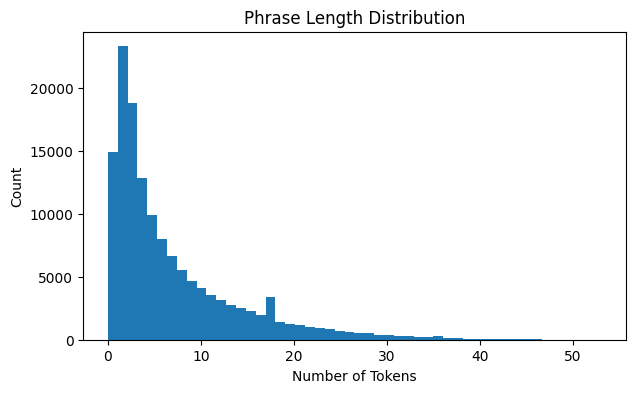

In [9]:
lengths = [len(tokens) for tokens in train_tokens]

print("Max length:", max(lengths))
print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("95% percentile:", np.percentile(lengths, 95))
print("99% percentile:", np.percentile(lengths, 99))

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=50)
plt.title("Phrase Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Count")
plt.show()

In [10]:
MAX_LEN = 40

In [11]:
MIN_FREQ = 2

counter = Counter()

for tokens in train_tokens:
    counter.update(tokens)

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

idx_to_word = {idx: word for word, idx in vocab.items()}

print("Vocab size:", len(vocab))
print("Most common words:", counter.most_common(20))

Vocab size: 16380
Most common words: [('the', 46050), (',', 37921), ('a', 32493), ('of', 29075), ('and', 28679), ('.', 22481), ('to', 20224), ("'s", 15251), ('in', 12378), ('is', 12099), ('that', 11093), ('it', 10496), ('as', 7794), ('with', 6967), ('for', 6671), ('its', 6352), ('film', 6007), ('an', 5858), ('movie', 5320), ('this', 5130)]


In [12]:
def encode_tokens(tokens, vocab, max_len):
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    
    if len(ids) > max_len:
        ids = ids[:max_len]
    else:
        ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))
    
    return ids

In [13]:
EMBED_DIM = 100

glove_vectors = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Loading GloVe"):
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_vectors[word] = vector

print("Loaded GloVe vectors:", len(glove_vectors))

Loading GloVe: 400000it [00:04, 98058.94it/s]

Loaded GloVe vectors: 400000


In [14]:
embedding_matrix = np.random.normal(
    scale=0.6,
    size=(len(vocab), EMBED_DIM)
).astype("float32")

# PAD token은 0 vector로 둔다
embedding_matrix[vocab["<PAD>"]] = np.zeros(EMBED_DIM)

found = 0

for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words found in GloVe:", found)
print("Coverage:", found / len(vocab))

Embedding matrix shape: (16380, 100)
Words found in GloVe: 15156
Coverage: 0.9252747252747253


## 6. Dataset 및 DataLoader 구성

PyTorch에서 학습을 진행하기 위해 custom Dataset class를 정의하였다.  
학습 및 검증 데이터에서는 input sequence와 label을 함께 반환하고, 테스트 데이터에서는 label이 없으므로 input sequence만 반환하도록 구성하였다.  
DataLoader는 mini-batch 단위 학습을 위해 사용하였으며, 학습 데이터에 대해서만 shuffle을 적용하였다.

In [15]:
class MovieReviewDataset(Dataset):
    def __init__(self, phrases, labels=None, vocab=None, max_len=40):
        self.phrases = phrases
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.phrases)
    
    def __getitem__(self, idx):
        text = self.phrases.iloc[idx]
        tokens = tokenize(text)
        input_ids = encode_tokens(tokens, self.vocab, self.max_len)
        
        input_ids = torch.tensor(input_ids, dtype=torch.long)
        
        if self.labels is not None:
            label = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
            return input_ids, label
        else:
            return input_ids

In [16]:
train_dataset = MovieReviewDataset(
    phrases=train_data["Phrase"],
    labels=train_data["Sentiment"],
    vocab=vocab,
    max_len=MAX_LEN
)

valid_dataset = MovieReviewDataset(
    phrases=valid_data["Phrase"],
    labels=valid_data["Sentiment"],
    vocab=vocab,
    max_len=MAX_LEN
)

test_dataset = MovieReviewDataset(
    phrases=test_df["Phrase"],
    labels=None,
    vocab=vocab,
    max_len=MAX_LEN
)

print("Train dataset:", len(train_dataset))
print("Valid dataset:", len(valid_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 140454
Valid dataset: 15606
Test dataset: 66292


In [17]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [18]:
batch = next(iter(train_loader))

input_ids, labels = batch

print("input_ids shape:", input_ids.shape)
print("labels shape:", labels.shape)

print("first input ids:", input_ids[0])
print("first label:", labels[0])

input_ids shape: torch.Size([128, 40])
labels shape: torch.Size([128])
first input ids: tensor([4561,  139,  884,   14, 1212,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
first label: tensor(1)


In [19]:
embedding_matrix_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

print(embedding_matrix_tensor.shape)

torch.Size([16380, 100])


## 7. 첫 번째 모델 구조: BiLSTM + Attention

첫 번째 모델은 GloVe 임베딩, BiLSTM layer, Attention layer, classifier로 구성하였다.  
감성 분석은 단어 sequence 전체를 입력받아 하나의 감성 label을 예측하는 many-to-one 분류 문제이므로, 문장의 앞뒤 문맥을 모두 반영할 수 있는 BiLSTM을 사용하였다.  
Attention layer는 각 token의 hidden state에 서로 다른 가중치를 부여하여, 감성 판단에 더 중요한 단어에 집중할 수 있도록 하기 위해 사용하였다.


In [20]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)
        
    def forward(self, lstm_outputs, mask):
        # lstm_outputs: [batch_size, seq_len, hidden_dim]
        # mask: [batch_size, seq_len]
        
        scores = self.attention(lstm_outputs).squeeze(-1)
        # scores: [batch_size, seq_len]
        
        # PAD token은 attention 계산에서 제외
        scores = scores.masked_fill(mask == 0, -1e9)
        
        attention_weights = torch.softmax(scores, dim=1)
        # attention_weights: [batch_size, seq_len]
        
        context = torch.bmm(
            attention_weights.unsqueeze(1),
            lstm_outputs
        ).squeeze(1)
        # context: [batch_size, hidden_dim]
        
        return context, attention_weights


class BiLSTMAttentionModel(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim=256,
        num_layers=2,
        num_classes=5,
        dropout=0.5,
        freeze_embedding=False,
        padding_idx=0
    ):
        super(BiLSTMAttentionModel, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        
        self.padding_idx = padding_idx
        
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=freeze_embedding,
            padding_idx=padding_idx
        )
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.attention = AttentionLayer(hidden_dim * 2)
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, input_ids):
        # input_ids: [batch_size, seq_len]
        
        mask = (input_ids != self.padding_idx)
        # mask: [batch_size, seq_len]
        
        embedded = self.embedding(input_ids)
        # embedded: [batch_size, seq_len, embedding_dim]
        
        lstm_outputs, _ = self.lstm(embedded)
        # lstm_outputs: [batch_size, seq_len, hidden_dim * 2]
        
        context, attention_weights = self.attention(lstm_outputs, mask)
        # context: [batch_size, hidden_dim * 2]
        
        logits = self.classifier(context)
        # logits: [batch_size, num_classes]
        
        return logits, attention_weights

In [21]:
model = BiLSTMAttentionModel(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=256,
    num_layers=2,
    num_classes=5,
    dropout=0.5,
    freeze_embedding=False,
    padding_idx=vocab["<PAD>"]
).to(device)

model

BiLSTMAttentionModel(
  (embedding): Embedding(16380, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=512, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [22]:
input_ids, labels = next(iter(train_loader))

input_ids = input_ids.to(device)
labels = labels.to(device)

logits, attention_weights = model(input_ids)

print("input_ids shape:", input_ids.shape)
print("logits shape:", logits.shape)
print("attention_weights shape:", attention_weights.shape)
print("labels shape:", labels.shape)

input_ids shape: torch.Size([128, 40])
logits shape: torch.Size([128, 5])
attention_weights shape: torch.Size([128, 40])
labels shape: torch.Size([128])


In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [24]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    
    for input_ids, labels in tqdm(dataloader, desc="Training"):
        input_ids = input_ids.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        logits, _ = model(input_ids)
        loss = criterion(logits, labels)
        
        loss.backward()
        
        # LSTM 계열에서 gradient가 너무 커지는 것을 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        preds = torch.argmax(logits, dim=1)
        
        total_loss += loss.item() * input_ids.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += input_ids.size(0)
    
    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    
    return avg_loss, avg_acc

In [25]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for input_ids, labels in tqdm(dataloader, desc="Evaluating"):
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            
            logits, _ = model(input_ids)
            loss = criterion(logits, labels)
            
            preds = torch.argmax(logits, dim=1)
            
            total_loss += loss.item() * input_ids.size(0)
            total_correct += (preds == labels).sum().item()
            total_count += input_ids.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    
    return avg_loss, avg_acc, all_preds, all_labels

## 8. BiLSTM + Attention 학습 및 결과

BiLSTM + Attention 모델을 5 epoch 동안 학습하였다.  
각 epoch마다 train loss, train accuracy, validation loss, validation accuracy를 기록하였고, validation accuracy가 가장 높은 모델을 best model로 저장하였다.  
학습이 실제로 진행되었는지 확인하고 과적합 여부를 보기 위해 loss와 accuracy 변화를 그래프로 시각화하였다.

In [26]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_valid_acc = 0.0
best_model_path = "./outputs/best_bilstm_attention.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
        model, valid_loader, criterion, device
    )
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved. Valid Acc: {best_valid_acc:.4f}")


Epoch 1/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 188.11it/s]


Train Loss: 0.9324 | Train Acc: 0.6187
Valid Loss: 0.8149 | Valid Acc: 0.6620
Best model saved. Valid Acc: 0.6620

Epoch 2/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 187.90it/s]


Train Loss: 0.7739 | Train Acc: 0.6768
Valid Loss: 0.7708 | Valid Acc: 0.6844
Best model saved. Valid Acc: 0.6844

Epoch 3/5


...

Train Loss: 0.7131 | Train Acc: 0.7010
Valid Loss: 0.7583 | Valid Acc: 0.6914
Best model saved. Valid Acc: 0.6914

Epoch 4/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 189.62it/s]


Train Loss: 0.6733 | Train Acc: 0.7152
Valid Loss: 0.7737 | Valid Acc: 0.6888

Epoch 5/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 191.24it/s]

Train Loss: 0.6431 | Train Acc: 0.7267
Valid Loss: 0.7848 | Valid Acc: 0.6888


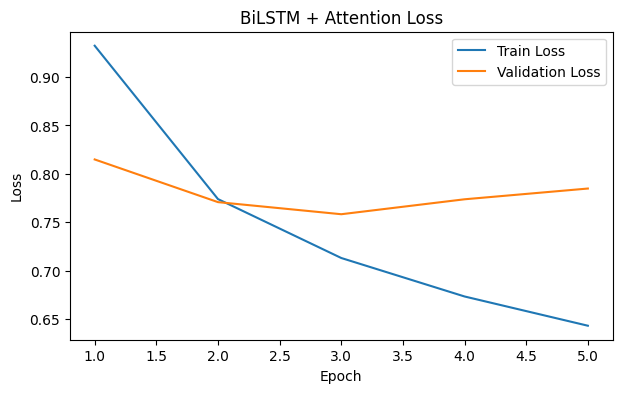

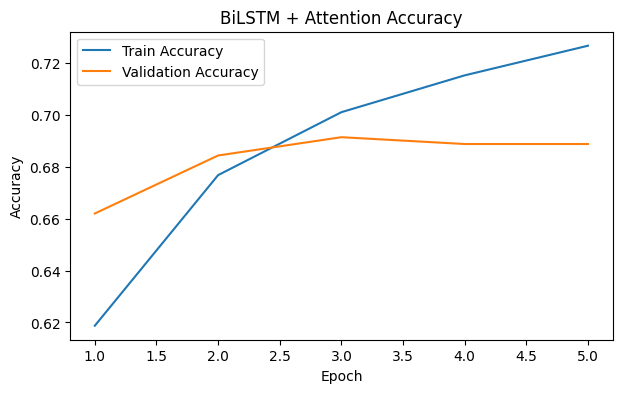

In [27]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM + Attention Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM + Attention Accuracy")
plt.legend()
plt.show()

In [28]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)

valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
    model, valid_loader, criterion, device
)

print(f"Best Loaded Model - Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

Evaluating: 100%|██████████| 122/122 [00:00<00:00, 193.36it/s]

Best Loaded Model - Valid Loss: 0.7583 | Valid Acc: 0.6914


In [29]:
model.load_state_dict(torch.load("./outputs/best_bilstm_attention.pt"))
model.to(device)
model.eval()

BiLSTMAttentionModel(
  (embedding): Embedding(16380, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=512, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

## 9. Kaggle 제출 파일 생성

저장된 best model을 불러온 뒤 Kaggle test dataset에 대한 감성 label을 예측하였다.  
예측 결과는 sample submission 형식에 맞게 `PhraseId`와 `Sentiment` 두 열로 구성하여 csv 파일로 저장하였다.

In [30]:
def predict_test(model, dataloader, device):
    model.eval()
    
    all_preds = []
    
    with torch.no_grad():
        for input_ids in tqdm(dataloader, desc="Predicting"):
            input_ids = input_ids.to(device)
            
            logits, _ = model(input_ids)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
    
    return all_preds

In [31]:
test_predictions = predict_test(model, test_loader, device)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:", test_predictions[:10])

Predicting: 100%|██████████| 518/518 [00:02<00:00, 230.83it/s]

Number of predictions: 66292
First 10 predictions: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2)]


In [55]:
submission = sample_df.copy()
submission["Sentiment"] = test_predictions

print(submission.head())
print(submission["Sentiment"].value_counts().sort_index())

submission_path = "./outputs/submission_bilstm_attention.csv"
submission.to_csv(submission_path, index=False)

print("Saved to:", submission_path)

   PhraseId  Sentiment
0    156061          2
1    156062          2
2    156063          2
3    156064          2
4    156065          2
Sentiment
0     1337
1    11248
2    39999
3    12117
4     1591
Name: count, dtype: int64
Saved to: ./outputs/submission_bilstm_attention.csv


## 10. BiLSTM + Attention 하이퍼파라미터 튜닝 1: Dropout 증가

기본 BiLSTM + Attention 모델에서 dropout 값을 0.5에서 0.6으로 증가시켜 실험하였다.  
Dropout을 증가시키면 학습 과정에서 일부 뉴런을 더 많이 비활성화하므로 과적합을 줄이는 효과를 기대할 수 있다.  
다른 구조와 학습 설정은 동일하게 유지하고, dropout 변화가 validation accuracy와 Kaggle score에 어떤 영향을 주는지 비교하였다.

In [41]:
bilstm_dropout_model = BiLSTMAttentionModel(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=256,
    num_layers=2,
    num_classes=5,
    dropout=0.6,
    freeze_embedding=False,
    padding_idx=vocab["<PAD>"]
).to(device)

bilstm_dropout_criterion = nn.CrossEntropyLoss()

bilstm_dropout_optimizer = torch.optim.Adam(
    bilstm_dropout_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [42]:
EPOCHS = 5

bilstm_dropout_history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_bilstm_dropout_valid_acc = 0.0
best_bilstm_dropout_model_path = "./outputs/best_bilstm_attention_dropout06.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        bilstm_dropout_model,
        train_loader,
        bilstm_dropout_criterion,
        bilstm_dropout_optimizer,
        device
    )
    
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
        bilstm_dropout_model,
        valid_loader,
        bilstm_dropout_criterion,
        device
    )
    
    bilstm_dropout_history["train_loss"].append(train_loss)
    bilstm_dropout_history["train_acc"].append(train_acc)
    bilstm_dropout_history["valid_loss"].append(valid_loss)
    bilstm_dropout_history["valid_acc"].append(valid_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    if valid_acc > best_bilstm_dropout_valid_acc:
        best_bilstm_dropout_valid_acc = valid_acc
        torch.save(bilstm_dropout_model.state_dict(), best_bilstm_dropout_model_path)
        print(f"Best dropout BiLSTM model saved. Valid Acc: {best_bilstm_dropout_valid_acc:.4f}")


Epoch 1/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 176.61it/s]


Train Loss: 0.9538 | Train Acc: 0.6102
Valid Loss: 0.8238 | Valid Acc: 0.6572
Best dropout BiLSTM model saved. Valid Acc: 0.6572

Epoch 2/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 187.23it/s]


Train Loss: 0.7863 | Train Acc: 0.6748
Valid Loss: 0.7832 | Valid Acc: 0.6795
Best dropout BiLSTM model saved. Valid Acc: 0.6795

Epoch 3/5


...

Train Loss: 0.7258 | Train Acc: 0.6961
Valid Loss: 0.7707 | Valid Acc: 0.6813
Best dropout BiLSTM model saved. Valid Acc: 0.6813

Epoch 4/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 166.77it/s]


Train Loss: 0.6846 | Train Acc: 0.7112
Valid Loss: 0.7683 | Valid Acc: 0.6861
Best dropout BiLSTM model saved. Valid Acc: 0.6861

Epoch 5/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 176.12it/s]

Train Loss: 0.6521 | Train Acc: 0.7220
Valid Loss: 0.7837 | Valid Acc: 0.6906
Best dropout BiLSTM model saved. Valid Acc: 0.6906


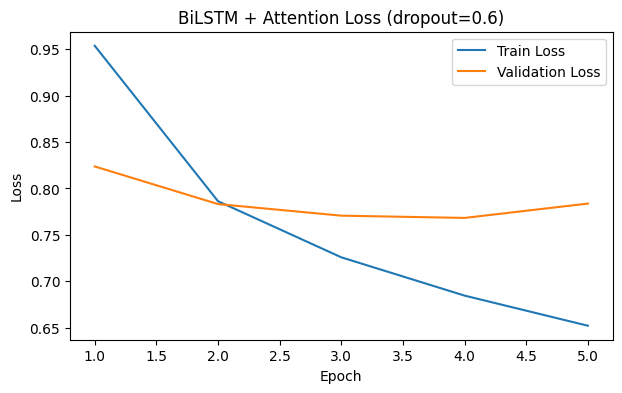

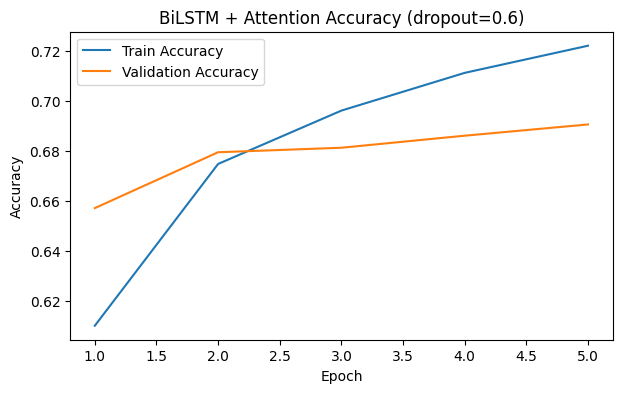

In [54]:
epochs_range = range(1, len(bilstm_dropout_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, bilstm_dropout_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, bilstm_dropout_history["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM + Attention Loss (dropout=0.6)")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, bilstm_dropout_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, bilstm_dropout_history["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM + Attention Accuracy (dropout=0.6)")
plt.legend()
plt.show()

In [45]:
bilstm_dropout_model.load_state_dict(torch.load(best_bilstm_dropout_model_path))
bilstm_dropout_model.to(device)
bilstm_dropout_model.eval()

BiLSTMAttentionModel(
  (embedding): Embedding(16380, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.6, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.6, inplace=False)
    (1): Linear(in_features=512, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [48]:
bilstm_dropout_test_predictions = predict_test(
    bilstm_dropout_model,
    test_loader,
    device
)

print("Number of predictions:", len(bilstm_dropout_test_predictions))
print("First 10 predictions:", bilstm_dropout_test_predictions[:10])

Predicting: 100%|██████████| 518/518 [00:02<00:00, 219.03it/s]

Number of predictions: 66292
First 10 predictions: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2)]


In [49]:
bilstm_dropout_submission = sample_df.copy()
bilstm_dropout_submission["Sentiment"] = bilstm_dropout_test_predictions

print(bilstm_dropout_submission.head())
print(bilstm_dropout_submission.shape)
print(bilstm_dropout_submission["Sentiment"].value_counts().sort_index())

bilstm_dropout_submission_path = "./outputs/submission_bilstm_attention_dropout06.csv"
bilstm_dropout_submission.to_csv(bilstm_dropout_submission_path, index=False)

print("Saved to:", bilstm_dropout_submission_path)

   PhraseId  Sentiment
0    156061          2
1    156062          2
2    156063          2
3    156064          2
4    156065          2
(66292, 2)
Sentiment
0      765
1    11247
2    39895
3    12971
4     1414
Name: count, dtype: int64
Saved to: ./outputs/submission_bilstm_attention_dropout06.csv


## 11. BiLSTM + Attention 하이퍼파라미터 튜닝 2: Learning rate 감소

두 번째 하이퍼파라미터 튜닝에서는 learning rate를 1e-3에서 5e-4로 낮추었다.  
Learning rate를 낮추면 parameter update의 폭이 작아져 학습이 더 안정적으로 진행될 수 있다.  
기본 모델과 동일한 구조를 사용하되 learning rate만 변경하여 성능 변화를 비교하였다.

In [43]:
bilstm_lr_model = BiLSTMAttentionModel(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=256,
    num_layers=2,
    num_classes=5,
    dropout=0.5,
    freeze_embedding=False,
    padding_idx=vocab["<PAD>"]
).to(device)

bilstm_lr_criterion = nn.CrossEntropyLoss()

bilstm_lr_optimizer = torch.optim.Adam(
    bilstm_lr_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

In [44]:
EPOCHS = 5

bilstm_lr_history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_bilstm_lr_valid_acc = 0.0
best_bilstm_lr_model_path = "./outputs/best_bilstm_attention_lr0005.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        bilstm_lr_model,
        train_loader,
        bilstm_lr_criterion,
        bilstm_lr_optimizer,
        device
    )
    
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
        bilstm_lr_model,
        valid_loader,
        bilstm_lr_criterion,
        device
    )
    
    bilstm_lr_history["train_loss"].append(train_loss)
    bilstm_lr_history["train_acc"].append(train_acc)
    bilstm_lr_history["valid_loss"].append(valid_loss)
    bilstm_lr_history["valid_acc"].append(valid_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    if valid_acc > best_bilstm_lr_valid_acc:
        best_bilstm_lr_valid_acc = valid_acc
        torch.save(bilstm_lr_model.state_dict(), best_bilstm_lr_model_path)
        print(f"Best LR-tuned BiLSTM model saved. Valid Acc: {best_bilstm_lr_valid_acc:.4f}")


Epoch 1/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 170.02it/s]


Train Loss: 0.9762 | Train Acc: 0.6012
Valid Loss: 0.8610 | Valid Acc: 0.6402
Best LR-tuned BiLSTM model saved. Valid Acc: 0.6402

Epoch 2/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 151.45it/s]


Train Loss: 0.8086 | Train Acc: 0.6648
Valid Loss: 0.7997 | Valid Acc: 0.6671
Best LR-tuned BiLSTM model saved. Valid Acc: 0.6671

Epoch 3/5


...

Train Loss: 0.7450 | Train Acc: 0.6896
Valid Loss: 0.7702 | Valid Acc: 0.6794
Best LR-tuned BiLSTM model saved. Valid Acc: 0.6794

Epoch 4/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 186.20it/s]


Train Loss: 0.7038 | Train Acc: 0.7058
Valid Loss: 0.7685 | Valid Acc: 0.6856
Best LR-tuned BiLSTM model saved. Valid Acc: 0.6856

Epoch 5/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 188.06it/s]

Train Loss: 0.6730 | Train Acc: 0.7172
Valid Loss: 0.7721 | Valid Acc: 0.6871
Best LR-tuned BiLSTM model saved. Valid Acc: 0.6871


In [50]:
bilstm_lr_model.load_state_dict(torch.load(best_bilstm_lr_model_path))
bilstm_lr_model.to(device)
bilstm_lr_model.eval()

bilstm_lr_valid_loss, bilstm_lr_valid_acc, bilstm_lr_valid_preds, bilstm_lr_valid_labels = evaluate(
    bilstm_lr_model,
    valid_loader,
    bilstm_lr_criterion,
    device
)

print(f"Best BiLSTM + Attention lr=5e-4 - Valid Loss: {bilstm_lr_valid_loss:.4f} | Valid Acc: {bilstm_lr_valid_acc:.4f}")

Evaluating: 100%|██████████| 122/122 [00:00<00:00, 179.73it/s]

Best BiLSTM + Attention lr=5e-4 - Valid Loss: 0.7721 | Valid Acc: 0.6871


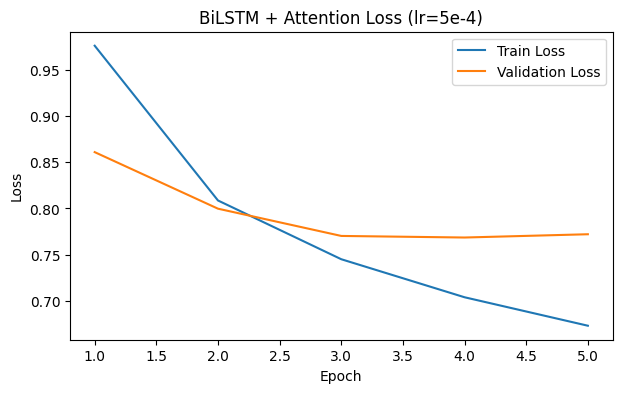

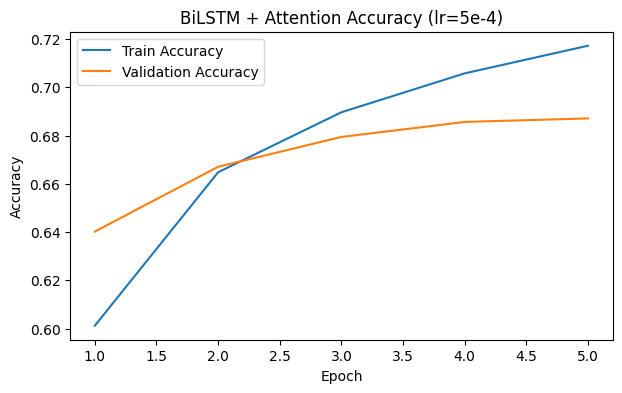

In [51]:
epochs_range = range(1, len(bilstm_lr_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, bilstm_lr_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, bilstm_lr_history["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM + Attention Loss (lr=5e-4)")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, bilstm_lr_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, bilstm_lr_history["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM + Attention Accuracy (lr=5e-4)")
plt.legend()
plt.show()

In [52]:
bilstm_lr_test_predictions = predict_test(
    bilstm_lr_model,
    test_loader,
    device
)

print("Number of predictions:", len(bilstm_lr_test_predictions))
print("First 10 predictions:", bilstm_lr_test_predictions[:10])

Predicting: 100%|██████████| 518/518 [00:02<00:00, 217.89it/s]

Number of predictions: 66292
First 10 predictions: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2)]


In [53]:
bilstm_lr_submission = sample_df.copy()
bilstm_lr_submission["Sentiment"] = bilstm_lr_test_predictions

print(bilstm_lr_submission.head())
print(bilstm_lr_submission.shape)
print(bilstm_lr_submission["Sentiment"].value_counts().sort_index())

bilstm_lr_submission_path = "./outputs/submission_bilstm_attention_lr0005.csv"
bilstm_lr_submission.to_csv(bilstm_lr_submission_path, index=False)

print("Saved to:", bilstm_lr_submission_path)

   PhraseId  Sentiment
0    156061          2
1    156062          2
2    156063          2
3    156064          2
4    156065          2
(66292, 2)
Sentiment
0     1737
1     9933
2    40163
3    11983
4     2476
Name: count, dtype: int64
Saved to: ./outputs/submission_bilstm_attention_lr0005.csv


## 12. 두 번째 모델 구조: BiGRU + Attention

BiLSTM과 비교하기 위해 recurrent layer를 GRU로 변경한 BiGRU + Attention 모델을 추가로 실험하였다.  
GRU는 LSTM보다 구조가 단순한 gated recurrent model이므로, 비슷한 구조에서 recurrent module의 차이가 성능에 어떤 영향을 주는지 비교할 수 있다.  
Embedding layer, Attention layer, classifier 구조는 BiLSTM 모델과 최대한 유사하게 유지하였다.

In [32]:
class BiGRUAttentionModel(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim=256,
        num_layers=2,
        num_classes=5,
        dropout=0.5,
        freeze_embedding=False,
        padding_idx=0
    ):
        super(BiGRUAttentionModel, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        self.padding_idx = padding_idx
        
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=freeze_embedding,
            padding_idx=padding_idx
        )
        
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # BiGRU output dimension = hidden_dim * 2
        self.attention = AttentionLayer(hidden_dim * 2)
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, input_ids):
        # input_ids: [batch_size, max_len]
        mask = (input_ids != self.padding_idx)
        
        # embedded: [batch_size, max_len, embedding_dim]
        embedded = self.embedding(input_ids)
        
        # gru_outputs: [batch_size, max_len, hidden_dim * 2]
        gru_outputs, _ = self.gru(embedded)
        
        # context: [batch_size, hidden_dim * 2]
        context, attention_weights = self.attention(gru_outputs, mask)
        
        # logits: [batch_size, num_classes]
        logits = self.classifier(context)
        
        return logits, attention_weights

In [33]:
gru_model = BiGRUAttentionModel(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=256,
    num_layers=2,
    num_classes=5,
    dropout=0.5,
    freeze_embedding=False,
    padding_idx=vocab["<PAD>"]
).to(device)

gru_model

BiGRUAttentionModel(
  (embedding): Embedding(16380, 100, padding_idx=0)
  (gru): GRU(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=512, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [34]:
input_ids, labels = next(iter(train_loader))

input_ids = input_ids.to(device)
labels = labels.to(device)

logits, attention_weights = gru_model(input_ids)

print("input_ids shape:", input_ids.shape)
print("logits shape:", logits.shape)
print("attention_weights shape:", attention_weights.shape)
print("labels shape:", labels.shape)

input_ids shape: torch.Size([128, 40])
logits shape: torch.Size([128, 5])
attention_weights shape: torch.Size([128, 40])
labels shape: torch.Size([128])


In [35]:
gru_criterion = nn.CrossEntropyLoss()

gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [36]:
EPOCHS = 5

gru_history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_gru_valid_acc = 0.0
best_gru_model_path = "./outputs/best_bigru_attention.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        gru_model, train_loader, gru_criterion, gru_optimizer, device
    )
    
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
        gru_model, valid_loader, gru_criterion, device
    )
    
    gru_history["train_loss"].append(train_loss)
    gru_history["train_acc"].append(train_acc)
    gru_history["valid_loss"].append(valid_loss)
    gru_history["valid_acc"].append(valid_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    if valid_acc > best_gru_valid_acc:
        best_gru_valid_acc = valid_acc
        torch.save(gru_model.state_dict(), best_gru_model_path)
        print(f"Best GRU model saved. Valid Acc: {best_gru_valid_acc:.4f}")


Epoch 1/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 200.02it/s]


Train Loss: 0.9237 | Train Acc: 0.6203
Valid Loss: 0.8190 | Valid Acc: 0.6592
Best GRU model saved. Valid Acc: 0.6592

Epoch 2/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 197.62it/s]


Train Loss: 0.7778 | Train Acc: 0.6754
Valid Loss: 0.7741 | Valid Acc: 0.6749
Best GRU model saved. Valid Acc: 0.6749

Epoch 3/5


...

Train Loss: 0.7159 | Train Acc: 0.6996
Valid Loss: 0.7795 | Valid Acc: 0.6838
Best GRU model saved. Valid Acc: 0.6838

Epoch 4/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 182.02it/s]


Train Loss: 0.6769 | Train Acc: 0.7136
Valid Loss: 0.7765 | Valid Acc: 0.6878
Best GRU model saved. Valid Acc: 0.6878

Epoch 5/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 188.97it/s]

Train Loss: 0.6467 | Train Acc: 0.7247
Valid Loss: 0.8013 | Valid Acc: 0.6836


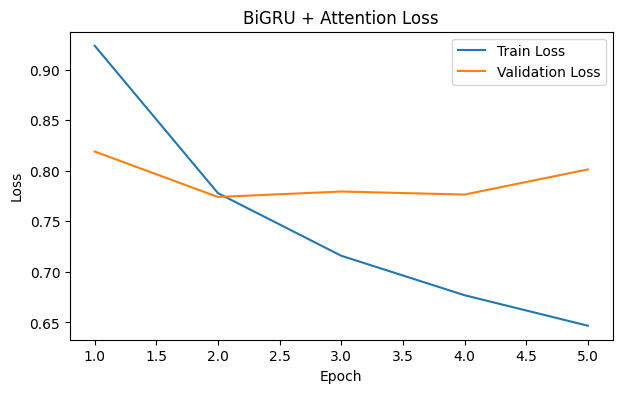

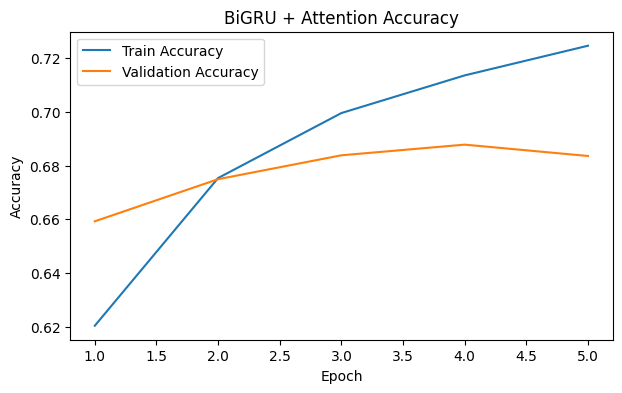

In [37]:
epochs_range = range(1, len(gru_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, gru_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, gru_history["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiGRU + Attention Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, gru_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, gru_history["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiGRU + Attention Accuracy")
plt.legend()
plt.show()

In [38]:
gru_model.load_state_dict(torch.load(best_gru_model_path))
gru_model.to(device)

gru_valid_loss, gru_valid_acc, gru_valid_preds, gru_valid_labels = evaluate(
    gru_model, valid_loader, gru_criterion, device
)

print(f"Best BiGRU + Attention - Valid Loss: {gru_valid_loss:.4f} | Valid Acc: {gru_valid_acc:.4f}")

Evaluating: 100%|██████████| 122/122 [00:00<00:00, 194.21it/s]

Best BiGRU + Attention - Valid Loss: 0.7765 | Valid Acc: 0.6878


In [39]:
gru_test_predictions = predict_test(gru_model, test_loader, device)

print("Number of predictions:", len(gru_test_predictions))
print("First 10 predictions:", gru_test_predictions[:10])

Predicting: 100%|██████████| 518/518 [00:02<00:00, 234.87it/s]

Number of predictions: 66292
First 10 predictions: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2)]


In [40]:
gru_submission = sample_df.copy()
gru_submission["Sentiment"] = gru_test_predictions

print(gru_submission.head())
print(gru_submission.shape)
print(gru_submission["Sentiment"].value_counts().sort_index())

gru_submission_path = "./outputs/submission_bigru_attention.csv"
gru_submission.to_csv(gru_submission_path, index=False)

print("Saved to:", gru_submission_path)

   PhraseId  Sentiment
0    156061          2
1    156062          2
2    156063          2
3    156064          2
4    156065          2
(66292, 2)
Sentiment
0     1726
1    10206
2    38373
3    13058
4     2929
Name: count, dtype: int64
Saved to: ./outputs/submission_bigru_attention.csv


## 13.BiGRU + Attention 하이퍼파라미터 튜닝 1: Dropout 증가

기본 BiGRU + Attention 모델에서 dropout 값을 0.5에서 0.6으로 증가시켰다.  
Dropout을 증가시키면 학습 과정에서 일부 뉴런을 더 많이 비활성화하므로 과적합을 줄이는 효과를 기대할 수 있다.  
다른 구조와 학습 설정은 동일하게 유지하고, dropout 변화가 validation accuracy와 Kaggle score에 어떤 영향을 주는지 비교하였다.

In [56]:
gru_dropout_model = BiGRUAttentionModel(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=256,
    num_layers=2,
    num_classes=5,
    dropout=0.6,
    freeze_embedding=False,
    padding_idx=vocab["<PAD>"]
).to(device)

gru_dropout_criterion = nn.CrossEntropyLoss()

gru_dropout_optimizer = torch.optim.Adam(
    gru_dropout_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [57]:
EPOCHS = 5

gru_dropout_history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_gru_dropout_valid_acc = 0.0
best_gru_dropout_model_path = "./outputs/best_bigru_attention_dropout06.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        gru_dropout_model,
        train_loader,
        gru_dropout_criterion,
        gru_dropout_optimizer,
        device
    )
    
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
        gru_dropout_model,
        valid_loader,
        gru_dropout_criterion,
        device
    )
    
    gru_dropout_history["train_loss"].append(train_loss)
    gru_dropout_history["train_acc"].append(train_acc)
    gru_dropout_history["valid_loss"].append(valid_loss)
    gru_dropout_history["valid_acc"].append(valid_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    if valid_acc > best_gru_dropout_valid_acc:
        best_gru_dropout_valid_acc = valid_acc
        torch.save(gru_dropout_model.state_dict(), best_gru_dropout_model_path)
        print(f"Best dropout BiGRU model saved. Valid Acc: {best_gru_dropout_valid_acc:.4f}")


Epoch 1/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 173.45it/s]


Train Loss: 0.9344 | Train Acc: 0.6176
Valid Loss: 0.8085 | Valid Acc: 0.6647
Best dropout BiGRU model saved. Valid Acc: 0.6647

Epoch 2/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 189.32it/s]


Train Loss: 0.7880 | Train Acc: 0.6732
Valid Loss: 0.7782 | Valid Acc: 0.6730
Best dropout BiGRU model saved. Valid Acc: 0.6730

Epoch 3/5


...

Train Loss: 0.7292 | Train Acc: 0.6947
Valid Loss: 0.7659 | Valid Acc: 0.6856
Best dropout BiGRU model saved. Valid Acc: 0.6856

Epoch 4/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 178.78it/s]


Train Loss: 0.6931 | Train Acc: 0.7067
Valid Loss: 0.7809 | Valid Acc: 0.6850

Epoch 5/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 183.67it/s]

Train Loss: 0.6656 | Train Acc: 0.7170
Valid Loss: 0.7855 | Valid Acc: 0.6908
Best dropout BiGRU model saved. Valid Acc: 0.6908


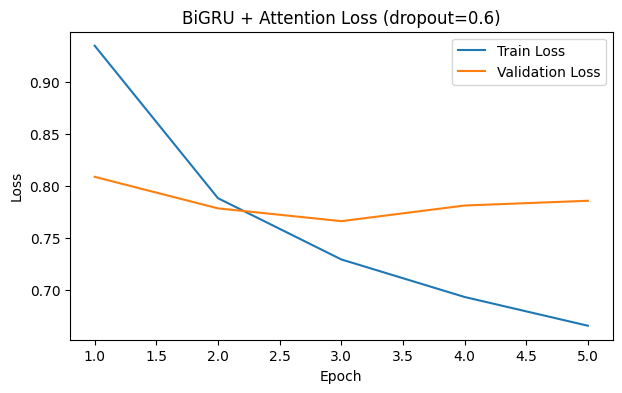

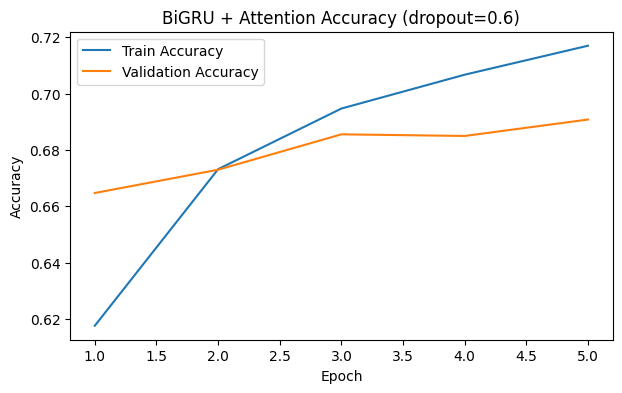

In [58]:
epochs_range = range(1, len(gru_dropout_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, gru_dropout_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, gru_dropout_history["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiGRU + Attention Loss (dropout=0.6)")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, gru_dropout_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, gru_dropout_history["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiGRU + Attention Accuracy (dropout=0.6)")
plt.legend()
plt.show()

In [59]:
gru_dropout_model.load_state_dict(torch.load(best_gru_dropout_model_path))
gru_dropout_model.to(device)
gru_dropout_model.eval()

gru_dropout_valid_loss, gru_dropout_valid_acc, gru_dropout_valid_preds, gru_dropout_valid_labels = evaluate(
    gru_dropout_model,
    valid_loader,
    gru_dropout_criterion,
    device
)

print(f"Best BiGRU + Attention dropout=0.6 - Valid Loss: {gru_dropout_valid_loss:.4f} | Valid Acc: {gru_dropout_valid_acc:.4f}")

Evaluating: 100%|██████████| 122/122 [00:00<00:00, 157.70it/s]

Best BiGRU + Attention dropout=0.6 - Valid Loss: 0.7855 | Valid Acc: 0.6908


In [60]:
gru_dropout_test_predictions = predict_test(
    gru_dropout_model,
    test_loader,
    device
)

print("Number of predictions:", len(gru_dropout_test_predictions))
print("First 10 predictions:", gru_dropout_test_predictions[:10])

Predicting: 100%|██████████| 518/518 [00:02<00:00, 237.99it/s]

Number of predictions: 66292
First 10 predictions: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2)]


In [61]:
gru_dropout_submission = sample_df.copy()
gru_dropout_submission["Sentiment"] = gru_dropout_test_predictions

print(gru_dropout_submission.head())
print(gru_dropout_submission.shape)
print(gru_dropout_submission["Sentiment"].value_counts().sort_index())

gru_dropout_submission_path = "./outputs/submission_bigru_attention_dropout06.csv"
gru_dropout_submission.to_csv(gru_dropout_submission_path, index=False)

print("Saved to:", gru_dropout_submission_path)

   PhraseId  Sentiment
0    156061          2
1    156062          2
2    156063          2
3    156064          2
4    156065          2
(66292, 2)
Sentiment
0     1511
1    10261
2    39606
3    12813
4     2101
Name: count, dtype: int64
Saved to: ./outputs/submission_bigru_attention_dropout06.csv


## 14. BiGRU + Attention 하이퍼파라미터 튜닝 2: Learning Rate 감소

두 번째 하이퍼파라미터 튜닝에서는 learning rate를 1e-3에서 5e-4로 낮추었다.  
Learning rate를 낮추면 parameter update의 폭이 작아져 학습이 더 안정적으로 진행될 수 있다.  
기본 BiGRU + Attention 모델과 동일한 구조를 사용하되 learning rate만 변경하여 성능 변화를 비교하였다.

In [63]:
gru_lr_model = BiGRUAttentionModel(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=256,
    num_layers=2,
    num_classes=5,
    dropout=0.5,
    freeze_embedding=False,
    padding_idx=vocab["<PAD>"]
).to(device)

gru_lr_criterion = nn.CrossEntropyLoss()

gru_lr_optimizer = torch.optim.Adam(
    gru_lr_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

In [65]:
EPOCHS = 5

gru_lr_history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_gru_lr_valid_acc = 0.0
best_gru_lr_model_path = "./outputs/best_bigru_attention_lr0005.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        gru_lr_model,
        train_loader,
        gru_lr_criterion,
        gru_lr_optimizer,
        device
    )
    
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
        gru_lr_model,
        valid_loader,
        gru_lr_criterion,
        device
    )
    
    gru_lr_history["train_loss"].append(train_loss)
    gru_lr_history["train_acc"].append(train_acc)
    gru_lr_history["valid_loss"].append(valid_loss)
    gru_lr_history["valid_acc"].append(valid_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    if valid_acc > best_gru_lr_valid_acc:
        best_gru_lr_valid_acc = valid_acc
        torch.save(gru_lr_model.state_dict(), best_gru_lr_model_path)
        print(f"Best LR-tuned BiGRU model saved. Valid Acc: {best_gru_lr_valid_acc:.4f}")


Epoch 1/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 194.22it/s]


Train Loss: 0.8144 | Train Acc: 0.6625
Valid Loss: 0.7981 | Valid Acc: 0.6664
Best LR-tuned BiGRU model saved. Valid Acc: 0.6664

Epoch 2/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 189.45it/s]


Train Loss: 0.7503 | Train Acc: 0.6873
Valid Loss: 0.7731 | Valid Acc: 0.6826
Best LR-tuned BiGRU model saved. Valid Acc: 0.6826

Epoch 3/5


...

Train Loss: 0.7072 | Train Acc: 0.7052
Valid Loss: 0.7653 | Valid Acc: 0.6871
Best LR-tuned BiGRU model saved. Valid Acc: 0.6871

Epoch 4/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 187.03it/s]


Train Loss: 0.6768 | Train Acc: 0.7159
Valid Loss: 0.7642 | Valid Acc: 0.6869

Epoch 5/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 185.51it/s]

Train Loss: 0.6510 | Train Acc: 0.7250
Valid Loss: 0.7672 | Valid Acc: 0.6876
Best LR-tuned BiGRU model saved. Valid Acc: 0.6876


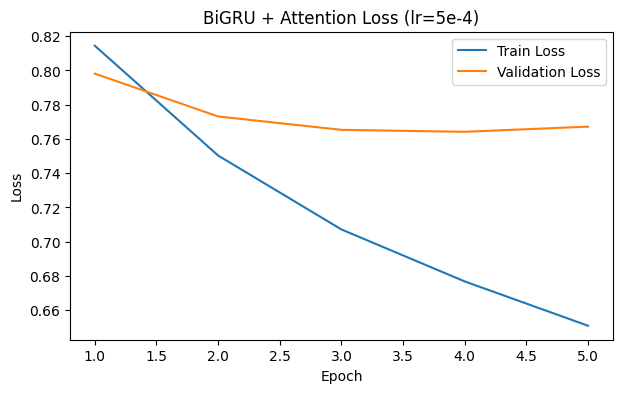

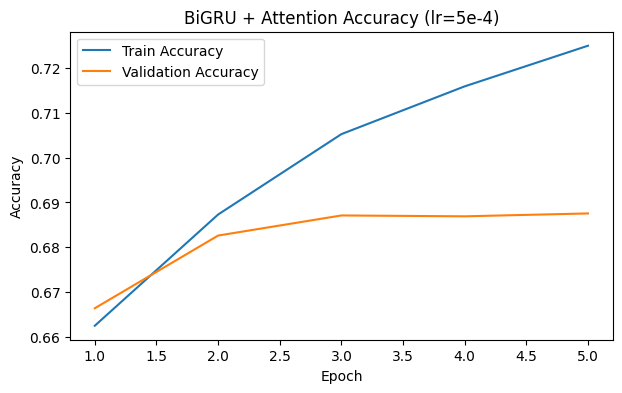

In [66]:
epochs_range = range(1, len(gru_lr_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, gru_lr_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, gru_lr_history["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiGRU + Attention Loss (lr=5e-4)")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, gru_lr_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, gru_lr_history["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiGRU + Attention Accuracy (lr=5e-4)")
plt.legend()
plt.show()

In [67]:
gru_lr_model.load_state_dict(torch.load(best_gru_lr_model_path))
gru_lr_model.to(device)
gru_lr_model.eval()

gru_lr_valid_loss, gru_lr_valid_acc, gru_lr_valid_preds, gru_lr_valid_labels = evaluate(
    gru_lr_model,
    valid_loader,
    gru_lr_criterion,
    device
)

print(f"Best BiGRU + Attention lr=5e-4 - Valid Loss: {gru_lr_valid_loss:.4f} | Valid Acc: {gru_lr_valid_acc:.4f}")

Evaluating: 100%|██████████| 122/122 [00:00<00:00, 161.01it/s]

Best BiGRU + Attention lr=5e-4 - Valid Loss: 0.7672 | Valid Acc: 0.6876


In [68]:
gru_lr_test_predictions = predict_test(
    gru_lr_model,
    test_loader,
    device
)

print("Number of predictions:", len(gru_lr_test_predictions))
print("First 10 predictions:", gru_lr_test_predictions[:10])

Predicting: 100%|██████████| 518/518 [00:02<00:00, 202.70it/s]

Number of predictions: 66292
First 10 predictions: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2)]


In [69]:
gru_lr_submission = sample_df.copy()
gru_lr_submission["Sentiment"] = gru_lr_test_predictions

print(gru_lr_submission.head())
print(gru_lr_submission.shape)
print(gru_lr_submission["Sentiment"].value_counts().sort_index())

gru_lr_submission_path = "./outputs/submission_bigru_attention_lr0005.csv"
gru_lr_submission.to_csv(gru_lr_submission_path, index=False)

print("Saved to:", gru_lr_submission_path)

   PhraseId  Sentiment
0    156061          3
1    156062          3
2    156063          2
3    156064          3
4    156065          3
(66292, 2)
Sentiment
0     1604
1     9839
2    39460
3    13289
4     2100
Name: count, dtype: int64
Saved to: ./outputs/submission_bigru_attention_lr0005.csv


## 15. 세 번째 모델 구조: Transformer Encoder

마지막 모델로 Transformer Encoder 기반 분류 모델을 실험하였다.  
이 모델은 GloVe embedding에 positional encoding을 더한 뒤, Transformer Encoder layer를 통과시켜 문장 내 token들 사이의 관계를 self-attention으로 학습한다.  
RNN 계열 모델인 BiLSTM, BiGRU와 달리 Transformer는 recurrent 구조를 사용하지 않고, self-attention을 통해 전체 sequence 정보를 한 번에 반영할 수 있다는 차이가 있다.
GloVe embedding과 PyTorch의 Transformer Encoder를 이용하여 직접 분류 모델을 구성하였다.

In [88]:
class PositionalEncoding(nn.Module):
    def __init__(self, embedding_dim, max_len=40, dropout=0.3):
        super(PositionalEncoding, self).__init__()
        
        self.dropout = nn.Dropout(dropout)
        
        pe = torch.zeros(max_len, embedding_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2).float() * 
            (-np.log(10000.0) / embedding_dim)
        )
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # pe shape: [1, max_len, embedding_dim]
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
        
    def forward(self, x):
        # x shape: [batch_size, max_len, embedding_dim]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [89]:
class TransformerEncoderModel(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        max_len=40,
        num_classes=5,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.2,
        freeze_embedding=False,
        padding_idx=0
    ):
        super(TransformerEncoderModel, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        self.padding_idx = padding_idx
        
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=freeze_embedding,
            padding_idx=padding_idx
        )
        
        self.positional_encoding = PositionalEncoding(
            embedding_dim=embedding_dim,
            max_len=max_len,
            dropout=dropout
        )
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        # Transformer output dimension is embedding_dim
        self.attention = AttentionLayer(embedding_dim)
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, input_ids):
        # input_ids: [batch_size, max_len]
        mask = (input_ids != self.padding_idx)
        padding_mask = (input_ids == self.padding_idx)
        
        # embedded: [batch_size, max_len, embedding_dim]
        embedded = self.embedding(input_ids)
        
        # Add positional information
        embedded = self.positional_encoding(embedded)
        
        # transformer_outputs: [batch_size, max_len, embedding_dim]
        transformer_outputs = self.transformer_encoder(
            embedded,
            src_key_padding_mask=padding_mask
        )
        
        # Attention pooling over token representations
        context, attention_weights = self.attention(transformer_outputs, mask)
        
        # logits: [batch_size, num_classes]
        logits = self.classifier(context)
        
        return logits, attention_weights

In [90]:
transformer_model = TransformerEncoderModel(
    embedding_matrix=embedding_matrix_tensor,
    max_len=MAX_LEN,
    num_classes=5,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    freeze_embedding=False,
    padding_idx=vocab["<PAD>"]
).to(device)

transformer_model

TransformerEncoderModel(
  (embedding): Embedding(16380, 100, padding_idx=0)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
        )
        (linear1): Linear(in_features=100, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=100, bias=True)
        (norm1): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (attention): AttentionLayer(
    (attention): Linear(in_features=100, out_features=1, bias=True)
  )
  (classi

In [91]:
input_ids, labels = next(iter(train_loader))

input_ids = input_ids.to(device)
labels = labels.to(device)

logits, attention_weights = transformer_model(input_ids)

print("input_ids shape:", input_ids.shape)
print("logits shape:", logits.shape)
print("attention_weights shape:", attention_weights.shape)
print("labels shape:", labels.shape)

input_ids shape: torch.Size([128, 40])
logits shape: torch.Size([128, 5])
attention_weights shape: torch.Size([128, 40])
labels shape: torch.Size([128])


In [92]:
transformer_criterion = nn.CrossEntropyLoss()

transformer_optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

In [93]:
EPOCHS = 5

transformer_history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_transformer_valid_acc = 0.0
best_transformer_model_path = "./outputs/best_transformer_encoder.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        transformer_model,
        train_loader,
        transformer_criterion,
        transformer_optimizer,
        device
    )
    
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(
        transformer_model,
        valid_loader,
        transformer_criterion,
        device
    )
    
    transformer_history["train_loss"].append(train_loss)
    transformer_history["train_acc"].append(train_acc)
    transformer_history["valid_loss"].append(valid_loss)
    transformer_history["valid_acc"].append(valid_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    if valid_acc > best_transformer_valid_acc:
        best_transformer_valid_acc = valid_acc
        torch.save(transformer_model.state_dict(), best_transformer_model_path)
        print(f"Best Transformer model saved. Valid Acc: {best_transformer_valid_acc:.4f}")


Epoch 1/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 280.11it/s]


Train Loss: 1.0293 | Train Acc: 0.5768
Valid Loss: 0.9115 | Valid Acc: 0.6246
Best Transformer model saved. Valid Acc: 0.6246

Epoch 2/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 285.03it/s]


Train Loss: 0.9129 | Train Acc: 0.6208
Valid Loss: 0.8557 | Valid Acc: 0.6473
Best Transformer model saved. Valid Acc: 0.6473

Epoch 3/5


...

Train Loss: 0.8573 | Train Acc: 0.6428
Valid Loss: 0.8222 | Valid Acc: 0.6601
Best Transformer model saved. Valid Acc: 0.6601

Epoch 4/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 283.61it/s]


Train Loss: 0.8180 | Train Acc: 0.6583
Valid Loss: 0.8101 | Valid Acc: 0.6676
Best Transformer model saved. Valid Acc: 0.6676

Epoch 5/5


Evaluating: 100%|██████████| 122/122 [00:00<00:00, 275.08it/s]

Train Loss: 0.7908 | Train Acc: 0.6694
Valid Loss: 0.8014 | Valid Acc: 0.6747
Best Transformer model saved. Valid Acc: 0.6747


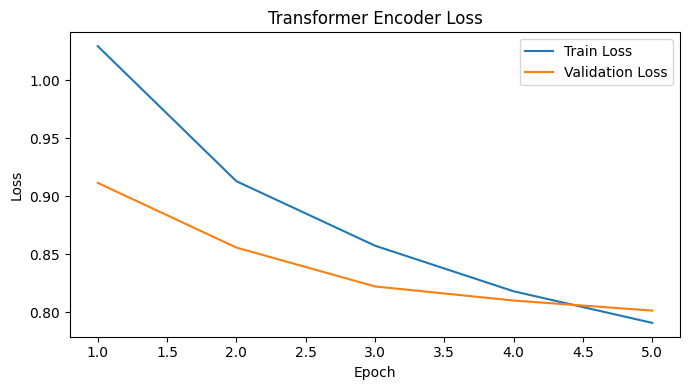

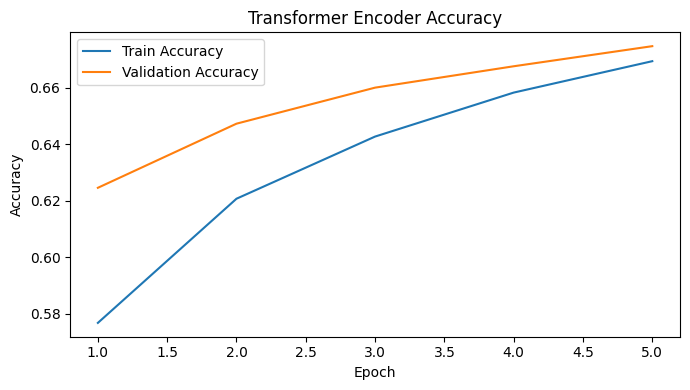

In [94]:
epochs_range = range(1, len(transformer_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, transformer_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, transformer_history["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Encoder Loss")
plt.legend()
plt.tight_layout()
plt.savefig("./outputs/transformer_encoder_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, transformer_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, transformer_history["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Encoder Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("./outputs/transformer_encoder_accuracy.png", dpi=300)
plt.show()

In [95]:
transformer_model.load_state_dict(torch.load(best_transformer_model_path))
transformer_model.to(device)
transformer_model.eval()

transformer_valid_loss, transformer_valid_acc, transformer_valid_preds, transformer_valid_labels = evaluate(
    transformer_model,
    valid_loader,
    transformer_criterion,
    device
)

print(f"Best Transformer Encoder - Valid Loss: {transformer_valid_loss:.4f} | Valid Acc: {transformer_valid_acc:.4f}")

Evaluating: 100%|██████████| 122/122 [00:00<00:00, 258.14it/s]

Best Transformer Encoder - Valid Loss: 0.8014 | Valid Acc: 0.6747


In [96]:
transformer_test_predictions = predict_test(
    transformer_model,
    test_loader,
    device
)

print("Number of predictions:", len(transformer_test_predictions))
print("First 10 predictions:", transformer_test_predictions[:10])

Predicting: 100%|██████████| 518/518 [00:01<00:00, 372.57it/s]

Number of predictions: 66292
First 10 predictions: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2)]


In [98]:
transformer_submission = sample_df.copy()
transformer_submission["Sentiment"] = transformer_test_predictions

print(transformer_submission.head())
print(transformer_submission.shape)
print(transformer_submission["Sentiment"].value_counts().sort_index())

transformer_submission_path = "./outputs/submission_transformer_encoder.csv"
transformer_submission.to_csv(transformer_submission_path, index=False)

print("Saved to:", transformer_submission_path)

   PhraseId  Sentiment
0    156061          3
1    156062          3
2    156063          2
3    156064          3
4    156065          3
(66292, 2)
Sentiment
0      736
1     8909
2    41162
3    13319
4     2166
Name: count, dtype: int64
Saved to: ./outputs/submission_transformer_encoder.csv
